In [2]:
import os
import numpy as np
from readers import cris_utils as c_utils
import matplotlib.pyplot as plt
import earthaccess
import glob
from datetime import datetime, timedelta
import xarray as xr
import re
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

/home/jturner/miniconda3/envs/spectral_analysis/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
today_date_str = datetime.now().strftime("%Y_%m_%d")

## Plotting CrIS spatially

In [4]:
cris_dir = "data/cris/from_earthaccess"
cris_date = "20250312" #YYYYMMDD
cris_pattern = os.path.join(cris_dir, f"SNDR.J1.CRIS.{cris_date}*")

cris_files = glob.glob(cris_pattern)
cris_files.sort() 
print(f"{len(cris_files)} CrIS files found...")
if not cris_files:
    print("CrIS files not found, downloading...")
    date_obj = datetime.strptime(cris_date, "%Y%m%d")
    sel_day_formatted = date_obj.strftime("%Y-%m-%d")
    next_day_formatted = (date_obj + timedelta(days=1)).strftime("%Y-%m-%d")
    cris_files = c_utils.download_cris_data(sel_day_formatted, next_day_formatted, cris_dir=cris_dir)

2 CrIS files found...


In [5]:
cris_files_sample = cris_files[:18]
print(f"Using {len(cris_files_sample)}/{len(cris_files)} of the files...")

wnum_sel_lw = 990
wnum_sel_sw = 2551

da_cris_lw, datetime_str = c_utils.create_cris_da(cris_files_sample, fov_sel=0, wnum_sel=wnum_sel_lw)
da_cris_sw, datetime_str = c_utils.create_cris_da(cris_files_sample, fov_sel=0, wnum_sel=wnum_sel_sw)

Tb_lw = c_utils.radiance_to_brightness_temp(da_cris_lw, wnum_sel_lw)
Tb_sw = c_utils.radiance_to_brightness_temp(da_cris_sw, wnum_sel_sw)

da_cris = Tb_lw - Tb_sw

Using 2/2 of the files...
Creating CrIS dataset...
Creating CrIS dataset...


In [6]:
#--- Creating CrIS average longwave band
def cris_custom_lw(cris_files_sample):
    wn_sel_lw_list = [1000, 999, 993, 992]
    wnum_sel_sw = 2551

    Tb_lw_list = []
    for wnum_sel_lw in wn_sel_lw_list:
        da_cris_lw, datetime_str = c_utils.create_cris_da(cris_files_sample, fov_sel=0, wnum_sel=wnum_sel_lw)
        Tb_lw = c_utils.radiance_to_brightness_temp(da_cris_lw, wnum_sel_lw)
        Tb_lw_list.append(Tb_lw)

    da_cris_sw, datetime_str = c_utils.create_cris_da(cris_files_sample, fov_sel=0, wnum_sel=wnum_sel_sw)
    Tb_sw = c_utils.radiance_to_brightness_temp(da_cris_sw, wnum_sel_sw)

    Tb_lw_stacked = xr.concat(Tb_lw_list, dim="wnum_sel")
    Tb_lw_average = Tb_lw_stacked.mean(dim="wnum_sel")

    return Tb_sw, Tb_lw_average

# Tb_sw, Tb_lw_average = cris_custom_lw(cris_files_sample)

# da_cris = Tb_lw_average - Tb_sw

In [7]:
def _add_pin_to_plot(ax, pin_coords):
    '''
    pin_coords: tuple of lat, lon; (36, -72)
    '''
    ax.plot(pin_coords[1], pin_coords[0], 
        marker='o', 
        markersize=12,
        markerfacecolor='red',
        markeredgecolor='white',
        markeredgewidth=1.5, 
        transform=ccrs.PlateCarree())
    return

Plotting CrIS radiance...


/home/jturner/miniconda3/envs/spectral_analysis/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


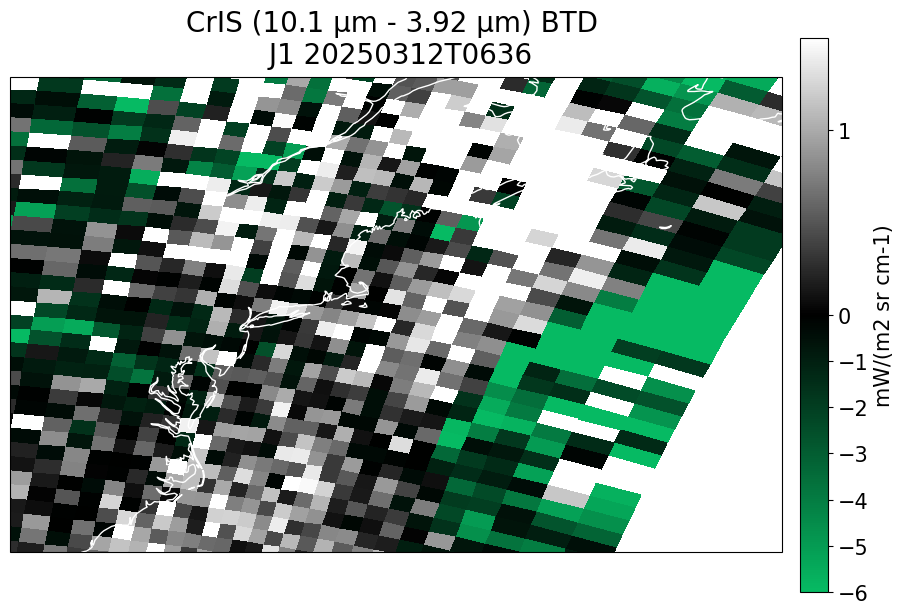

In [8]:
print(f"Plotting CrIS radiance...")
projection=ccrs.PlateCarree(central_longitude=0)
fig,ax=plt.subplots(1, figsize=(12,12),subplot_kw={'projection': projection})

cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#06BA63"), (0.5, "black"), (1, "white")]
)
norm = mcolors.TwoSlopeNorm(vmin=-6, vcenter=0, vmax=1.5)

pcm = ax.pcolormesh(da_cris['lon'], da_cris['lat'], da_cris, cmap=cmap, norm=norm, shading="nearest")

clb = plt.colorbar(pcm, ax=ax, shrink=0.6, pad=0.02)
clb.ax.tick_params(labelsize=15)
clb.set_label("mW/(m2 sr cm-1)", fontsize=15)

# _add_pin_to_plot(ax, pin_coords=(41.6, -67.5))

wl_sel_lw = round(10_000/wnum_sel_lw, 2)
wl_sel_sw = round(10_000/wnum_sel_sw, 2)
description = f"{cris_files_sample[0].split(".")[1]} {cris_files_sample[0].split(".")[3]}"
plot_title = f"CrIS ({wl_sel_lw} μm - {wl_sel_sw} μm) BTD \n {description}"
# plot_title = f"CrIS ([{round(10_000/1000, 2)}, {round(10_000/999, 2)}, {round(10_000/993, 2)}, {round(10_000/992, 2)}] μm - {wl_sel_sw} μm) BTD \n {description}"
ax.set_title(plot_title, fontsize=20, pad=10)

ax.set_extent([-82, -56, 33, 49], crs=ccrs.PlateCarree())
ax.coastlines(resolution='50m', color='white', linewidth=1)

plt.savefig(f"plots/{today_date_str}_cris_spatial_{wnum_sel_lw}.png",
            dpi=600, bbox_inches='tight')

plt.show()

## Plotting spectra from a point

In [9]:
cris_dir = "data/cris/from_earthaccess/"
cris_file = "SNDR.J1.CRIS.20250312T0636.m06.g067.L1B.std.v03_08.G.250312132413.nc"
file_path = os.path.join(cris_dir, cris_file)

In [10]:
cris_target_lat = 41.6
cris_target_lon = -67.5

ds = c_utils.open_cris_data(file_path)
ds, actual_lat, actual_lon = c_utils.isolate_target_point(ds, target_lat=cris_target_lat, target_lon=cris_target_lon)
df_lw = c_utils.get_brightness_temperature(ds, spectra_sel="lw")
df_mw = c_utils.get_brightness_temperature(ds, spectra_sel="mw")
df_sw = c_utils.get_brightness_temperature(ds, spectra_sel="sw")

Using lat/lon of 44.51, -67.48, fov of 7


In [11]:
def add_vertical_lines(wnum_sel_sw, wnum_sel_lw):
    """
    :param wnum_sel_sw: list or float
    :param wnum_sel_lw: list or float
    """
    wnum_sel_sw = np.atleast_1d(wnum_sel_sw)
    wnum_sel_lw = np.atleast_1d(wnum_sel_lw)

    for x_sw in wnum_sel_sw:
        ax.axvline(x=x_sw, linestyle='--', color="#C83E4D")
    for x_lw in wnum_sel_lw:
        ax.axvline(x=x_lw, linestyle='--', color="#06BA63")

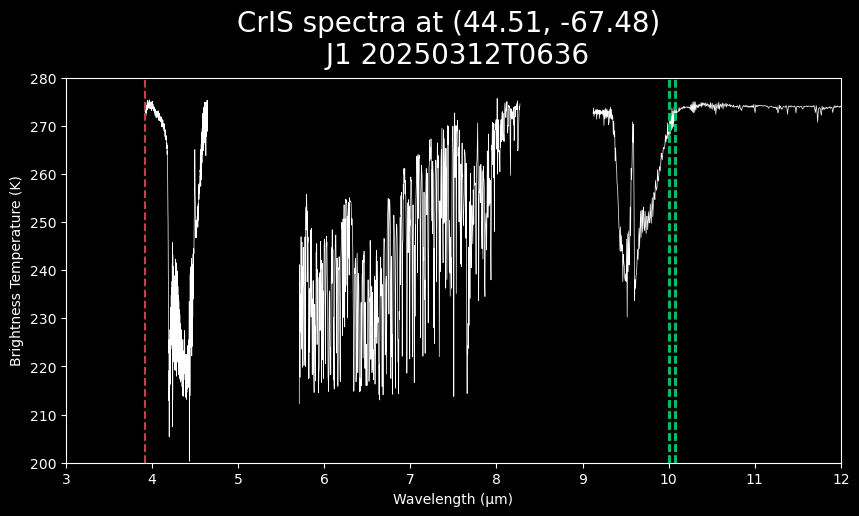

In [12]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('black')

ax.plot(df_lw["Wavelength (um)"], 
        df_lw["Brightness Temperature (K)"], 
        color="#fff", 
        linewidth=0.5)
ax.plot(df_mw["Wavelength (um)"], 
        df_mw["Brightness Temperature (K)"], 
        color="#fff", 
        linewidth=0.5)
ax.plot(df_sw["Wavelength (um)"], 
        df_sw["Brightness Temperature (K)"], 
        color="#fff", 
        linewidth=0.5)

add_vertical_lines(wnum_sel_sw=10_000/2551, wnum_sel_lw=10_000/np.array([1000, 999, 993, 992]))

ax.set_xlim((3,12))
ax.set_ylim((200,280))

ax.set_xlabel("Wavelength (μm)")
ax.set_ylabel("Brightness Temperature (K)")

plot_title = f"CrIS spectra at ({actual_lat}, {actual_lon}) \n {description}"
ax.set_title(plot_title, fontsize=20, pad=10)

plt.savefig(f"plots/{today_date_str}_cris_spectra.png", dpi=600, bbox_inches='tight')
plt.show()

## Plotting CrIS on CLAVR-x grid

In [13]:
cris_on_clavrx_ds = xr.open_dataset("data/processed_datasets/coloc_cris-clavrx_2026_05_14.nc")

In [14]:
cris_on_clavrx_sel = cris_on_clavrx_ds.sel(wnum_lw=660, method='nearest')

In [17]:
#--- Downsampling for faster plotting
fy, fx = 9, 9
latitudes_ds = cris_on_clavrx_sel['latitude'][::fy, ::fx]
longitudes_ds = cris_on_clavrx_sel['longitude'][::fy, ::fx]
rad_lw_ds = cris_on_clavrx_sel['rad_lw_cris'][::fy, ::fx]

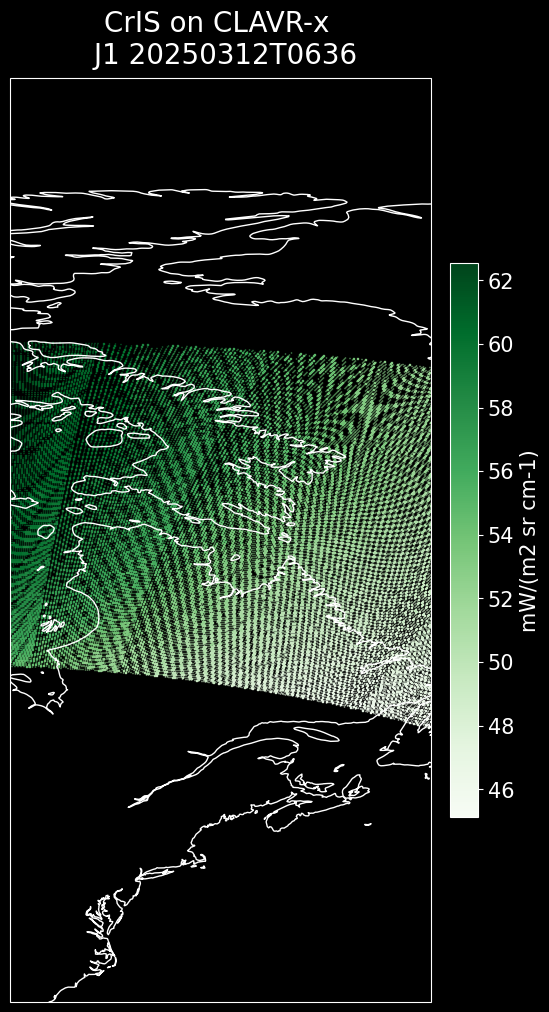

In [ ]:
projection=ccrs.PlateCarree(central_longitude=0)
fig,ax=plt.subplots(1, figsize=(12,12),subplot_kw={'projection': projection})

sc = ax.scatter(longitudes_ds, latitudes_ds, 
           c=rad_lw_ds, 
           transform=ccrs.PlateCarree(), 
           cmap="Greens",
           s=0.1, marker='s')

clb = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
clb.ax.tick_params(labelsize=15)
clb.set_label("mW/(m2 sr cm-1)", fontsize=15)


description = f"{cris_files_sample[0].split(".")[1]} {cris_files_sample[0].split(".")[3]}"
plot_title = f"CrIS on CLAVR-x \n {description}"
ax.set_title(plot_title, fontsize=20, pad=10)

ax.set_extent([-82, -56, 33, 90], crs=ccrs.PlateCarree())
ax.coastlines(resolution='50m', color='white', linewidth=1)

plt.savefig(f"plots/{today_date_str}_coloc_cris-clavrx.png",
            dpi=600, bbox_inches='tight')

plt.show()

Use CrIS spectra and SRF to get brightness temperature:

In [ ]:
import sys
sys.exit()

In [12]:
srf_file = "data/spectral_response_functions/NPP_VIIRS_NG_RSR_M12_filtered_Oct2011f_BA.dat"

#--- flip direction to match to SRF
spectra_wl = df_cris['Wavelength (um)'][::-1]
spectra_t = df_cris['Brightness Temperature (K)'][::-1]

#--- Load SRF, which is in wavelengths and proportions
srf = np.loadtxt(srf_file)
srf_wl = np.array(srf[:, 0]/1000) # Convert from nm to µm
srf_response = np.array(srf[:, 1])

#--- Interpolate Tb onto the SRF wavelength grid
from scipy.interpolate import interp1d
interp_rad = interp1d(spectra_wl, spectra_t, kind='linear', bounds_error=False, fill_value=np.nan)
Tb_array = interp_rad(srf_wl)

#--- Remove missing data from SRF arrays
mask = ~np.isnan(Tb_array)
Tb_array = Tb_array[mask]
srf_response = srf_response[mask]
srf_wl = srf_wl[mask]

#------ Trapezoid method to get Tb multiplied by normalized SRF
Tb = np.trapezoid(Tb_array * srf_response, srf_wl) / np.trapezoid(srf_response, srf_wl) 
print(f"Brightness temperature: {Tb:.2f} K")

NameError: name 'df_cris' is not defined

## Plot a CrIS block

*Does not work currently*

In [ ]:
ds = c_utils.open_cris_data("data/cris/from_earthaccess/SNDR.J1.CRIS.20260306T0024.m06.g005.L1B.std.v03_08.G.260306075422.nc")

FileNotFoundError: [Errno 2] No such file or directory: '/local/home/jturner/spectral_analysis/data/cris/from_earthaccess/SNDR.J1.CRIS.20260306T0024.m06.g005.L1B.std.v03_08.G.260306075422.nc'

IndexError: too many indices for array: array is 1-dimensional, but 4 were indexed

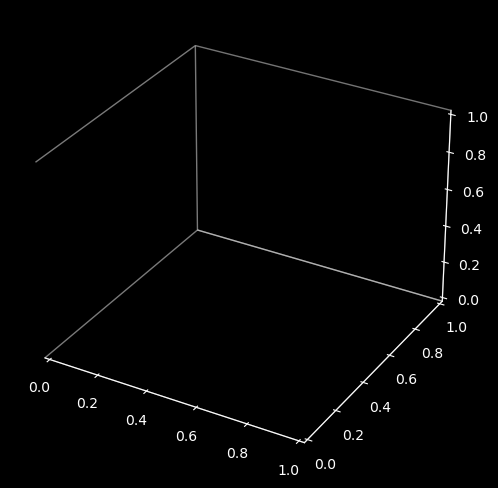

In [ ]:
import matplotlib.colors as mcolors

rad = ds['wnum_lw'].values
x = ds['xtrack'].values
y = ds['atrack'].values
z = ds['wnum_lw'].values

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(8, 6), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

#--- Make background clean
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)

#--- Color scaling
vmin = np.min(rad)
vmax = np.max(rad)
cmap = mcolors.LinearSegmentedColormap.from_list(
            "custom_cmap",
            [(0, "#A9A9A9"), (0.5, "white"), (1, "#1167b1")]
        )
norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)

#--- Plot stacked slices
set_min = 150 # Customizing the appearance of the stack
set_max = 550
for i in range(set_min,set_max):
    rad_i = rad[:,:,0,i]

    ax.contourf(
        X, Y, rad_i,
        levels=10,
        zdir='z',
        offset=z[i],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
        ) 

#--- Viewing angle
ax.set_zlim(z[set_min], z[set_max])
ax.view_init(elev=25, azim=-60)

plt.savefig(f"plots/{today_date_str}_cris_block.png", dpi=200, bbox_inches='tight')
plt.show()